# **ETAPES D'ETUDE SERIE TEMPORELLE**
### 1️⃣ **Compréhension du problème**
- Objectif : description, prévision, détection d’anomalies ?
- Horizon de prévision : court, moyen, long terme ?
- Granularité temporelle : jour, mois, année, heure ?\
👉 Exemple : prévoir les ventes mensuelles pour les 6 prochains mois.
### 2️⃣ **Collecte et préparation des données**
- Conversion des dates (datetime)
- Mise en index temporel
- Vérification de la fréquence régulière
- Traitement des valeurs manquantes (interpolation, moyenne, suppression)
- Suppression ou traitement des valeurs aberrantes\
✅ Résultat : une série propre et ordonnée dans le temps
### 3️⃣ **Analyse descriptive (EDA temporelle)**
### a) Visualisation de la série
- Tracé de la série
- Observation de : tendance, saisonnalité, Bruit
### b) Statistiques simples
- moyenne, variance
- minimum, maximum
### 4️⃣ **Décomposition de la série temporelle**
**Séparer la série en composantes :**
- Tendance (Trend)
- Saisonnalité (Seasonal)
- Résidu/Bruit (Residual)\
**📌 Modèles :**
- Additif : ``Y = T + S + R``
- Multiplicatif : ``Y = T × S × R``
### 5️⃣ **Étude de la stationnarité**
- **Pourquoi ?**
La plupart des algorithmes de séries temporelles nécessitent que la série soit stationnaire.
(moyenne et variance constantes dans le temps)
- **Tests statistiques :**
ADF (Augmented Dickey-Fuller)\
    $H_0$ : série non stationnaire\
    $H_1$ : série stationnaire

### 6️⃣ **Transformation de la série (si nécessaire)**
Si la série n’est pas stationnaire :
- Différenciation :
$Y_t − Y_{t-1}$
- Différenciation saisonnière
- Logarithme (réduction de la variance)
- Combinaison (log + diff)\
🎯 Objectif : obtenir une série stationnaire
### 7️⃣ **Analyse ACF et PACF**
- ACF (Autocorrelation Function)\
Relation entre les valeurs (choix le parametre q(MA))
- PACF (Partial Autocorrelation Function)\
Relation entre les valeurs dans le serie(choix de parametre p (AR))
### 8️⃣ **Choix du modèle de série temporelle**

### **I. Importation des Bibliotheque**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2️⃣ **Collecte et préparation des données**
- Conversion des dates (datetime)
- Mise en index temporel
- Vérification de la fréquence régulière
- Traitement des valeurs manquantes (interpolation, moyenne, suppression)
- Suppression ou traitement des valeurs aberrantes

In [21]:
# df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv",index_col=0)
df = pd.read_csv("../data/Passenger.csv",index_col=0)
data = df
print(df.shape)
df.head()

(144, 1)


,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


### **1. Conversion des dates (datetime)**

In [22]:
data.index = pd.to_datetime(data.index)
print(type(data.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


### **2. Vérification de la fréquence régulière**

In [23]:
print(data.index.freq)

None


In [24]:
data = data.asfreq('MS')   # Début de mois (Month Start)
# data = data.asfreq('ME')    # Fin de mois (Month End)
print(data.index.freq)
data.head()

<MonthBegin>


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### **3. Traitement des valeurs manquantes (interpolation, moyenne, suppression) et les doublons**

In [25]:
print(data.isna().sum())
print('----------Doublons-------------')
data.duplicated().sum()

Passengers    0
dtype: int64
----------Doublons-------------


26

## 3️⃣ **Analyse descriptive (EDA temporelle)**
### **a) Visualisation de la série**
- Tracé de la série
- Observation de : tendance, saisonnalité, Bruit

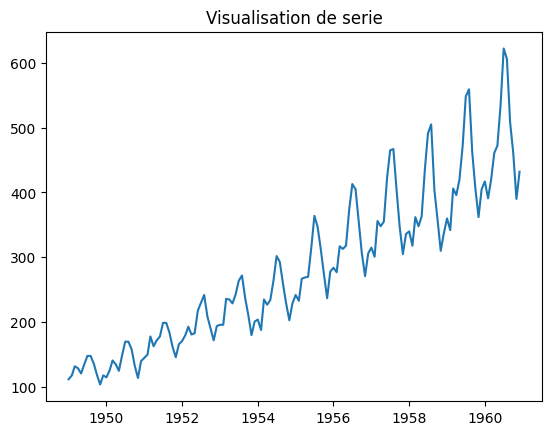

In [26]:
plt.plot(data)
plt.title('Visualisation de serie')
plt.show()

In [27]:
data.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


**NB**: La série présente une tendance, une saisonnalité et un certain niveau de bruit. Comme il s’agit d’un modèle multiplicatif, on applique une transformation logarithmique afin de le convertir en modèle additif.

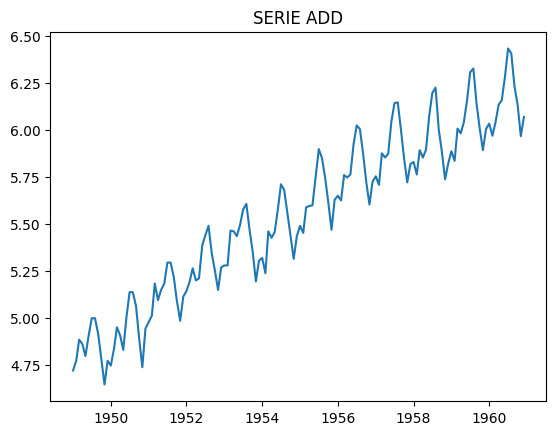

In [28]:
data = np.log(data)
plt.plot(data)
plt.title('SERIE ADD')
plt.show()

### **b) Statistiques simples**
- moyenne, variance
- minimum, maximum

In [29]:
data.describe()

,Passengers
count,144.000000
mean,5.542176
std,0.441456
min,4.644391
25%,5.192957
50%,5.581599
75%,5.887489
max,6.432940


## 4️⃣ Décomposition de la série temporelle
**Séparer la série en composantes :**
- Tendance (Trend)
- Saisonnalité (Seasonal)
- Résidu/Bruit (Residual)

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose #Importation de module de décomposition

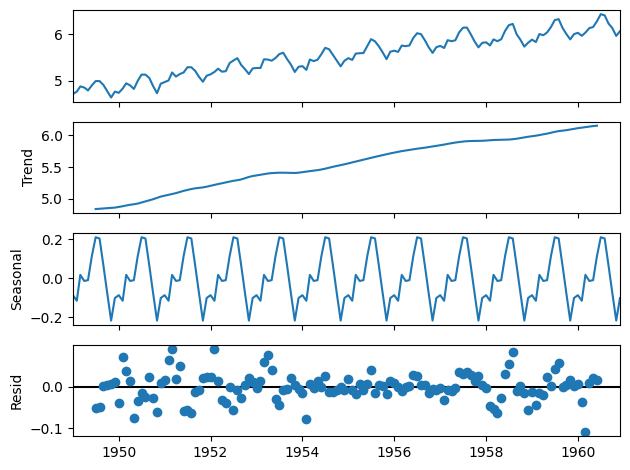

In [12]:
tsa = seasonal_decompose(data, period=12,)
tsa.plot()
plt.show()

## 5️⃣ Étude de la stationnarité
**Tests statistiques :**
ADF (Augmented Dickey-Fuller)\
    $H_0$ : série non stationnaire\
    $H_1$ : série stationnaire

**Décision**:
- si p-values<0,05 on rejete $H_0$ donc le serie est stationnaire\
- si p-values>0,05 on accepte $H_0$ donc le serie non stationnaire

In [31]:
from statsmodels.tsa.stattools import adfuller
def stationnaire(data):
    test = adfuller(data)
    print('p-value:',test[1])
    if test[1]<0.05:
        print('Le Série est stationnaire')
    else:
        print('Le Série est non stationnaire')

stationnaire(data=data)

p-value: 0.42236677477039125
Le Série est non stationnaire


## 6️⃣ Transformation de la série (si nécessaire)
Une série non stationnaire doit être transformée en série stationnaire à l’aide de la méthode de différenciation :  
- La première différenciation élimine la tendance linéaire ;  
- La deuxième différenciation élimine la tendance polynomiale ;  
- La différenciation d’ordre $s$ permet de supprimer la saisonnalité.

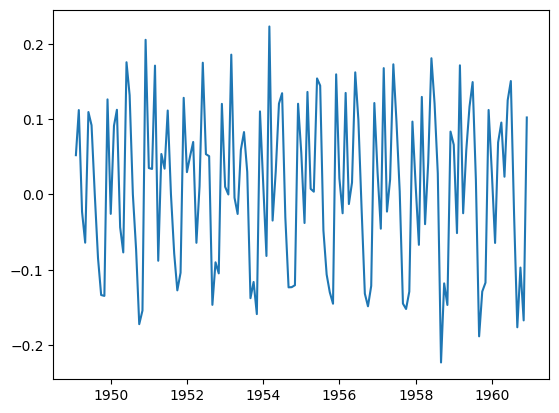

In [32]:
data = data.diff()
plt.plot(data.dropna())
plt.show()

In [33]:
stationnaire(data=data.dropna())

p-value: 0.07112054815085875
Le Série est non stationnaire


In [34]:
data= data.diff(12)
data = data.dropna()
stationnaire(data=data)

p-value: 0.00024859123113840924
Le Série est stationnaire


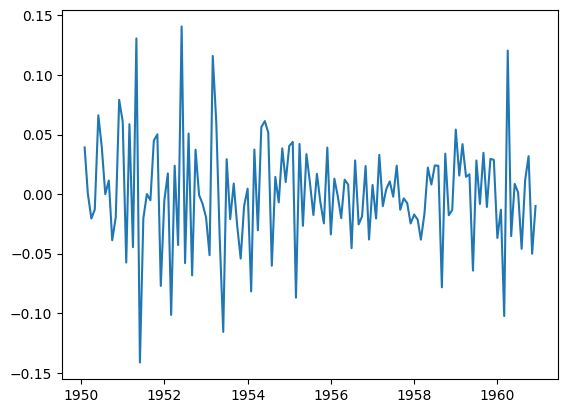

In [35]:
plt.plot(data)
plt.show()

## **7️⃣ Analyse ACF et PACF**
**Objectif:** 
- ACF sert à mesurer la dépendance entre une série temporelle et ses valeurs passées afin d’identifier la présence de corrélation et aider à choisir l’ordre MA (q).
- PACF sert à mesurer l’effet direct des valeurs passées, en éliminant l’influence intermédiaire, afin d’identifier l’ordre AR (p).\
**Résumé**

| Graphique | Sert à déterminer |
| --------- | ----------------- |
| **PACF**  | **p (AR)**        |
| **ACF**   | **q (MA)**        |

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x600 with 0 Axes>

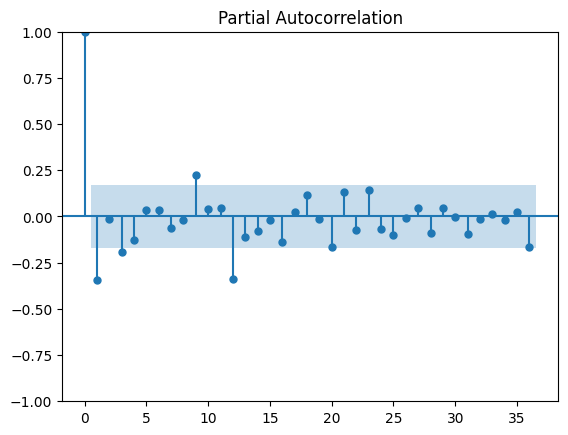

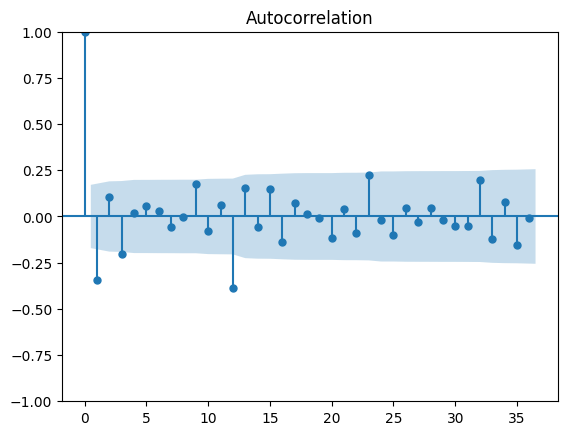

In [37]:
plt.figure(figsize=(10,6))
plot_pacf(data,lags=36)
plot_acf(data,lags=36)
plt.show()

## 8️⃣ Quel modèle? Quels paramètres?
> Modèle ARMA(1,1)
- p=1 : *regarde le passé de la série*
- q=1 : *regarde les erreurs du passé*
> Pour ordre de saisonnaires
- P=0
- Q=1

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(\
    data,\
    order=(p, d, q),\
    seasonal_order=(P, D, Q, s)\
)

In [39]:
model = SARIMAX(
    data,
    order=(1,1,1),
    seasonal_order=(0,1,1,12)
)
sarima = model.fit()
print(sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  131
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 181.261
Date:                            Wed, 24 Dec 2025   AIC                           -354.522
Time:                                    14:58:33   BIC                           -343.439
Sample:                                02-01-1950   HQIC                          -350.022
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3448      0.070     -4.941      0.000      -0.482      -0.208
ma.L1         -0.9951      0.555   

## **9. Modélisation avec PyCaret**

In [40]:
from pycaret.time_series import *

In [41]:
# exp = TSForecastingExperiment()
s = setup(
    data=df,
    fh=12,                     # horizon de prévision
    fold=3,
    seasonal_period=12,       # données mensuelles
    session_id=123
)

,Description,Value
0,session_id,123
1,Target,Passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(132, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [42]:
best_model = compare_models()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
exp_smooth,Exponential Smoothing,0.5716,0.5997,16.7778,19.7963,0.0422,0.0427,0.8954,0.1133
ets,ETS,0.5931,0.6212,17.4165,20.5103,0.0440,0.0445,0.8882,0.1667
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.6632,0.7313,19.5494,24.1881,0.0486,0.0486,0.8449,0.8667
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.6813,0.7866,20.0334,25.9670,0.0491,0.0499,0.8113,0.3367
arima,ARIMA,0.6830,0.6735,20.0069,22.2199,0.0501,0.0507,0.8677,0.1067
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.7004,0.7702,20.6084,25.4401,0.0509,0.0514,0.8215,0.9133
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.7004,0.7703,20.6086,25.4405,0.0509,0.0514,0.8215,0.3133
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.7029,0.7732,20.6816,25.5362,0.0511,0.0516,0.8201,0.7500
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.7048,0.7751,20.7373,25.6005,0.0512,0.0517,0.8193,0.3467
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.7048,0.7751,20.7366,25.6009,0.0512,0.0517,0.8192,0.5700


In [43]:
# model = create_model(best_model)
model = create_model('exp_smooth')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1956-12,0.4987,0.5736,14.5618,18.7763,0.0366,0.0376,0.8852
1,1957-12,0.5088,0.5368,15.5559,18.2249,0.0420,0.0411,0.9130
2,1958-12,0.7075,0.6887,20.2157,22.3876,0.0479,0.0494,0.8879
Mean,NaT,0.5716,0.5997,16.7778,19.7963,0.0422,0.0427,0.8954
SD,NaT,0.0961,0.0647,2.4646,1.8461,0.0046,0.0049,0.0125


In [44]:
tuned = tune_model(model)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1956-12,0.3971,0.4070,11.5974,13.3218,0.0310,0.0308,0.9422
1,1957-12,0.7419,0.7463,22.6834,25.3354,0.0632,0.0607,0.8318
2,1958-12,0.6797,0.7647,19.4222,24.8561,0.0423,0.0437,0.8618
Mean,NaT,0.6063,0.6393,17.9010,21.1711,0.0455,0.0451,0.8786
SD,NaT,0.1500,0.1644,4.6519,5.5537,0.0133,0.0122,0.0466


Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    9.1s finished


In [46]:
plot_model(model,plot='ts') # Visualisation de serie
plot_model(model,plot='acf') # Autocorrelation 
plot_model(model,plot='pacf') # Autocorrelation partielle
plot_model(model,plot='decomp') # Decomposition (tendance, saisonnalite, residu)
# plot_model(model,plot='dist')

In [47]:
finalize_model(model)

ForecastingPipeline(steps=[('forecaster',
                            TransformedTargetForecaster(steps=[('model',
                                                                ExponentialSmoothing(seasonal='mul',
                                                                                     sp=12,
                                                                                     trend='add'))]))])

In [54]:
# new_data = {'Month':[1961-1,1961-2,1961-3]}
# new = pd.DataFrame(new_data)
# new['Month'] = pd.to_datetime(new['Month'])
predict_model(model,fh=12)

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Exponential Smoothing,0.3384,0.4576,10.3031,15.8104,0.0221,0.0216,0.9549


,y_pred
1960-01,417.2853
1960-02,394.0617
1960-03,462.4440
1960-04,448.5977
1960-05,471.8700
1960-06,539.8935
1960-07,623.8229
1960-08,631.1540
1960-09,515.5804
1960-10,449.9018


In [55]:
save_model(model,'../model/model_de_serieTemp')

Transformation Pipeline and Model Successfully Saved


(ForecastingPipeline(steps=[('forecaster',
                             TransformedTargetForecaster(steps=[('model',
                                                                 ExponentialSmoothing(seasonal='mul',
                                                                                      sp=12,
                                                                                      trend='add'))]))]),
 '../model/model_de_serieTemp.pkl')

In [57]:
plot_model(model,plot='insample')

In [58]:
plot_model(model,plot='forecast')

In [59]:
plot_model(model,plot='residuals')